In [ ]:
!pip install biopython

In [13]:
import csv
import math
from Bio import Entrez
from Bio import SeqIO
import matplotlib.pyplot as plt

In [5]:
Entrez.email = "znshr.zulfa@apps.ipb.ac.id"

In [6]:
dict_aksesi = {}

print("=== PROGRAM IDENTIFIKASI BAKTERI KONTAMINAN PANGAN ===")

jumlah_bakteri = int(input("berapa bakteri yang mau dianalisis? "))

for i in range(jumlah_bakteri):
    print(f"\nbakteri ke-{i+1}:")
    nama_input = input("nama bakteri: ")
    nama_bersih = nama_input.strip().replace(" ", "_")
    aksesi = input("ID aksesi NCBI: ").strip()
    dict_aksesi[nama_bersih] = aksesi

nama_file_fasta = "bakteri_pangan_ncbi.fasta"

print("\nMulai download dari NCBI...")

# download sekuens dan simpan ke file fasta
fasta_out = open(nama_file_fasta, "w")

for nama_bakteri, id_aksesi in dict_aksesi.items():
    try:
        handle = Entrez.efetch(db="nucleotide", id=id_aksesi, rettype="fasta", retmode="text")
        record = SeqIO.read(handle, "fasta")
        handle.close()

        sekuens_bersih = str(record.seq).strip()
        fasta_out.write(">" + nama_bakteri + "_" + id_aksesi + "\n" + sekuens_bersih + "\n")
        print("berhasil download: " + nama_bakteri + " (" + id_aksesi + ")")

    except Exception as e:
        print("gagal download " + nama_bakteri + ": " + str(e))

fasta_out.close()
print("\nselesai, semua data tersimpan di: " + nama_file_fasta)

=== PROGRAM IDENTIFIKASI BAKTERI KONTAMINAN PANGAN ===
berapa bakteri yang mau dianalisis? 5

bakteri ke-1:
nama bakteri: Salmonella enterica
ID aksesi NCBI: NR_074910.1

bakteri ke-2:
nama bakteri: Escherichia coli
ID aksesi NCBI: NR_114042.1

bakteri ke-3:
nama bakteri: Listeria monocytogenes
ID aksesi NCBI: NR_074724.1

bakteri ke-4:
nama bakteri: Campylobacter jejuni
ID aksesi NCBI: NR_112586.1

bakteri ke-5:
nama bakteri: Staphylococcus aureus
ID aksesi NCBI: NR_118965.1

Mulai download dari NCBI...
berhasil download: Salmonella_enterica (NR_074910.1)
berhasil download: Escherichia_coli (NR_114042.1)
berhasil download: Listeria_monocytogenes (NR_074724.1)
berhasil download: Campylobacter_jejuni (NR_112586.1)
berhasil download: Staphylococcus_aureus (NR_118965.1)

selesai, semua data tersimpan di: bakteri_pangan_ncbi.fasta


In [14]:
# baca file fasta dan simpan ke list
data_bakteri = []

file = open(nama_file_fasta, "r")
nama_bakteri = ""
sekuens = ""

for line in file:
    line = line.strip()
    if line.startswith(">"):
        if nama_bakteri != "":
            data_bakteri.append([nama_bakteri, sekuens])
        nama_bakteri = line[1:]
        sekuens = ""
    else:
        sekuens = sekuens + line

if nama_bakteri != "":
    data_bakteri.append([nama_bakteri, sekuens])

file.close()

# hitung frekuensi nukleotida dan GC content
hasil_analisis = []

for bakteri, seq in data_bakteri:
    frekuensi = {'A': 0, 'T': 0, 'G': 0, 'C': 0}

    for basa in seq.upper():
        if basa in frekuensi:
            frekuensi[basa] += 1

    total_basa = frekuensi['A'] + frekuensi['T'] + frekuensi['G'] + frekuensi['C']
    jumlah_gc = frekuensi['G'] + frekuensi['C']

    if total_basa > 0:
        gc_content = (jumlah_gc / total_basa) * 100
    else:
        gc_content = 0

    # rumus estimasi Tm dari literatur
    na_konsentrasi = 0.05
    if total_basa > 0:
        gc_persen = (jumlah_gc / total_basa) * 100
        tm_estimasi = 81.5 + 16.6 * math.log10(na_konsentrasi) + 0.41 * gc_persen - 675 / total_basa
    else:
        tm_estimasi = 0

    hasil_analisis.append({
        'bakteri': bakteri,
        'panjang_seq': total_basa,
        'frekuensi': frekuensi,
        'gc_content': round(gc_content, 2),
        'tm_estimasi': round(tm_estimasi, 2)
    })

hasil_analisis_sorted = sorted(hasil_analisis, key=lambda x: x['gc_content'], reverse=True)

# tampilkan 3 teratas
print("=== 3 SEKUENS DENGAN GC CONTENT TERTINGGI ===")
for i in range(3):
    if i >= len(hasil_analisis_sorted):
        break
    data = hasil_analisis_sorted[i]
    print(str(i+1) + ". " + data['bakteri'])
    print("   panjang: " + str(data['panjang_seq']) + " bp")
    print("   frekuensi: " + str(data['frekuensi']))
    print("   GC content: " + str(data['gc_content']) + "%")
    print("   estimasi Tm: " + str(data['tm_estimasi']) + " C")
    print()

=== 3 SEKUENS DENGAN GC CONTENT TERTINGGI ===
1. Campylobacter_jejuni_NR_112586.1
   panjang: 1482 bp
   frekuensi: {'A': 332, 'T': 266, 'G': 506, 'C': 378}
   GC content: 59.65%
   estimasi Tm: 83.9 C

2. Listeria_monocytogenes_NR_074724.1
   panjang: 1528 bp
   frekuensi: {'A': 383, 'T': 301, 'G': 491, 'C': 353}
   GC content: 55.24%
   estimasi Tm: 82.11 C

3. Escherichia_coli_NR_114042.1
   panjang: 1464 bp
   frekuensi: {'A': 368, 'T': 292, 'G': 467, 'C': 337}
   GC content: 54.92%
   estimasi Tm: 81.96 C



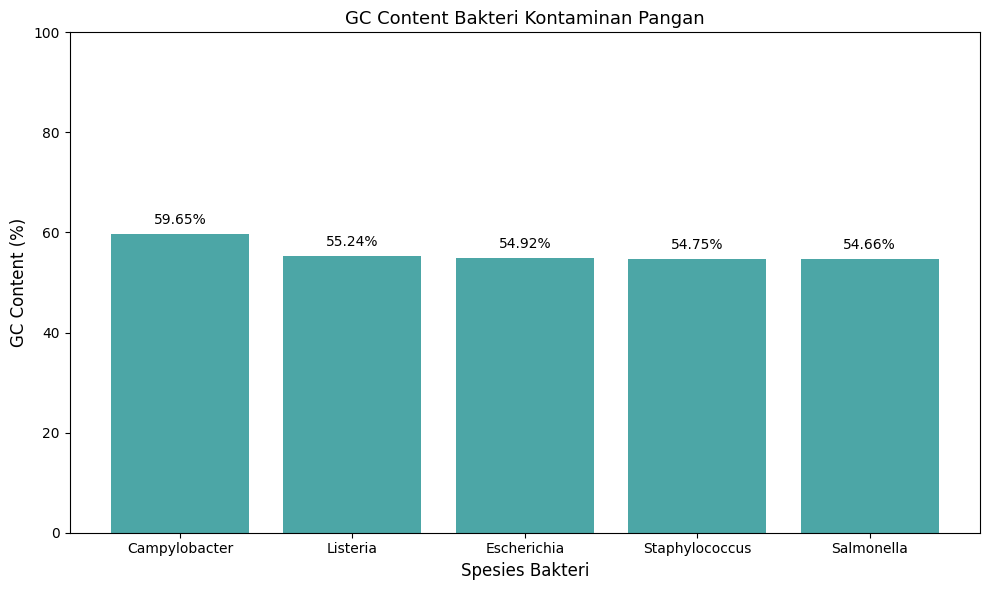

In [15]:
nama_bakteri_list = []
for data in hasil_analisis_sorted:
    nama_bakteri_list.append(data['bakteri'].split('_')[0])

gc_values = []
for data in hasil_analisis_sorted:
    gc_values.append(data['gc_content'])

tm_values = []
for data in hasil_analisis_sorted:
    tm_values.append(data['tm_estimasi'])

# grafik 1: GC content
fig1, ax1 = plt.subplots(figsize=(10, 6))

bars = ax1.bar(nama_bakteri_list, gc_values, color='teal', alpha=0.7)
ax1.set_xlabel('Spesies Bakteri', fontsize=12)
ax1.set_ylabel('GC Content (%)', fontsize=12)
ax1.set_ylim(0, 100)

for bar in bars:
    tinggi = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, tinggi + 2, str(tinggi) + "%", ha='center', fontsize=10)

plt.title('GC Content Bakteri Kontaminan Pangan', fontsize=13)
fig1.tight_layout()
plt.show()

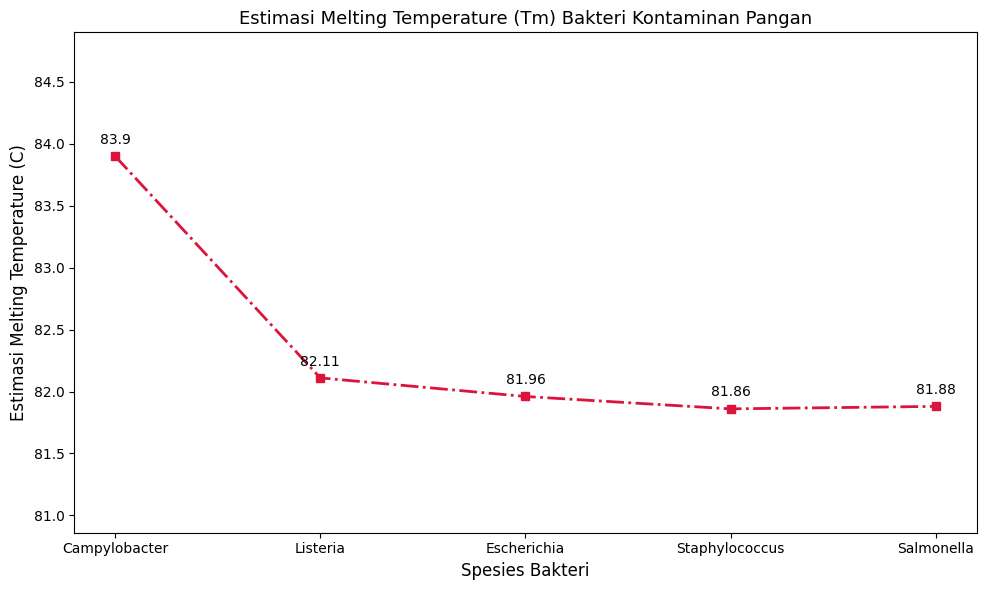

In [18]:
# grafik 2: estimasi melting temperature
fig2, ax2 = plt.subplots(figsize=(10, 6))

ax2.plot(nama_bakteri_list, tm_values, color='crimson', marker='s', linewidth=2, linestyle='-.')
ax2.set_xlabel('Spesies Bakteri', fontsize=12)
ax2.set_ylabel('Estimasi Melting Temperature (C)', fontsize=12)

for i, tm in enumerate(tm_values):
    ax2.text(i, tm + 0.1, str(tm), ha='center', fontsize=10)

ax2.set_ylim(min(tm_values) - 1, max(tm_values) + 1)

plt.title('Estimasi Melting Temperature (Tm) Bakteri Kontaminan Pangan', fontsize=13)
fig2.tight_layout()
plt.show()

In [17]:
# simpan ke CSV
nama_file_csv = "hasil_analisis_food_safety_ncbi.csv"

headers = ['Nama Bakteri', 'Panjang Sekuens (bp)', 'Jumlah A', 'Jumlah T', 'Jumlah G', 'Jumlah C', 'GC Content (%)', 'Estimasi Tm (C)']

file_csv = open(nama_file_csv, mode='w', newline='')
writer = csv.writer(file_csv)
writer.writerow(headers)

for data in hasil_analisis_sorted:
    baris = [
        data['bakteri'],
        data['panjang_seq'],
        data['frekuensi']['A'],
        data['frekuensi']['T'],
        data['frekuensi']['G'],
        data['frekuensi']['C'],
        data['gc_content'],
        data['tm_estimasi']
    ]
    writer.writerow(baris)

file_csv.close()
print("hasil analisis disimpan di: " + nama_file_csv)

hasil analisis disimpan di: hasil_analisis_food_safety_ncbi.csv
